EDA (Exploratory Data Analysis)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cleaned_retail_store_sales.csv")
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Year,Month,Day Name
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,2024,4,Monday
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,2023,7,Sunday
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,2022,10,Wednesday
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False,2022,5,Saturday
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,2022,10,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,False,2023,9,Sunday
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False,2022,8,Friday
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,False,2024,8,Saturday
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True,2023,12,Saturday


In [3]:
#Question 1: Which Product Category Generates Highest Sales?
category_sales = df.groupby('Category')['Total Spent'].sum()
print(category_sales)

Category
Beverages                             204751.0
Butchers                              215930.0
Computers and electric accessories    199481.0
Electric household essentials         211951.0
Food                                  203600.5
Furniture                             202471.0
Milk Products                         187815.5
Patisserie                            191605.0
Name: Total Spent, dtype: float64


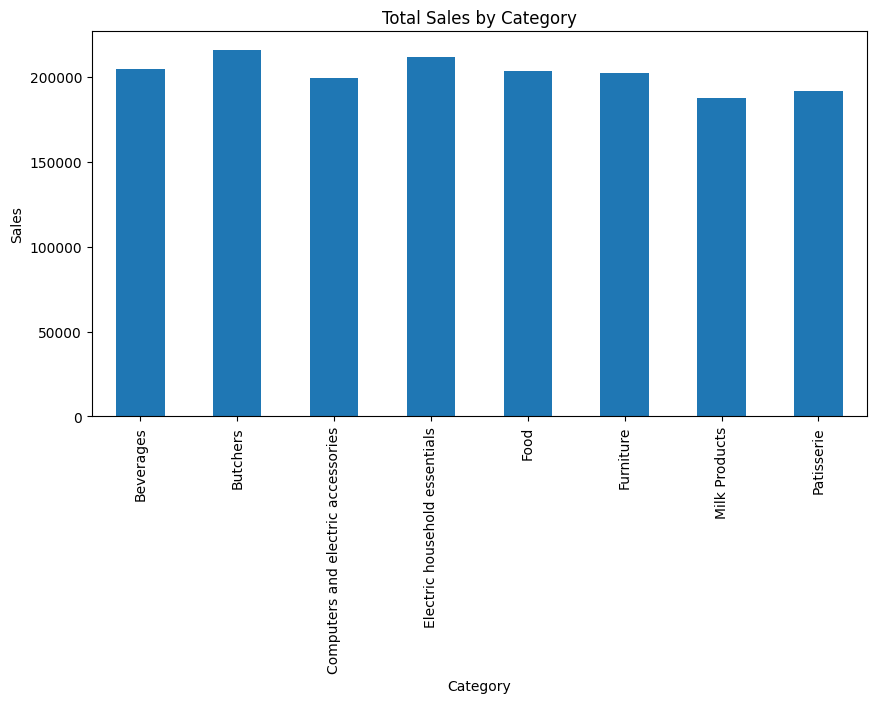

In [4]:
#Create Bar Chart
plt.figure(figsize=(10,5))

category_sales.plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')

plt.show()

In [5]:
# Question 2: Which Items Are Sold the Most?
top_items = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False) #Count Item Quantity
top_10_items = top_items.head(10) #Show Top 10 Items

print(top_10_items)

Item
Unknown Item    7011.0
Item_2_BEV       676.0
Item_16_MILK     627.0
Item_25_FUR      616.0
Item_19_MILK     589.0
Item_13_FOOD     581.0
Item_5_FUR       581.0
Item_1_MILK      578.0
Item_11_MILK     574.0
Item_11_FUR      573.0
Name: Quantity, dtype: float64


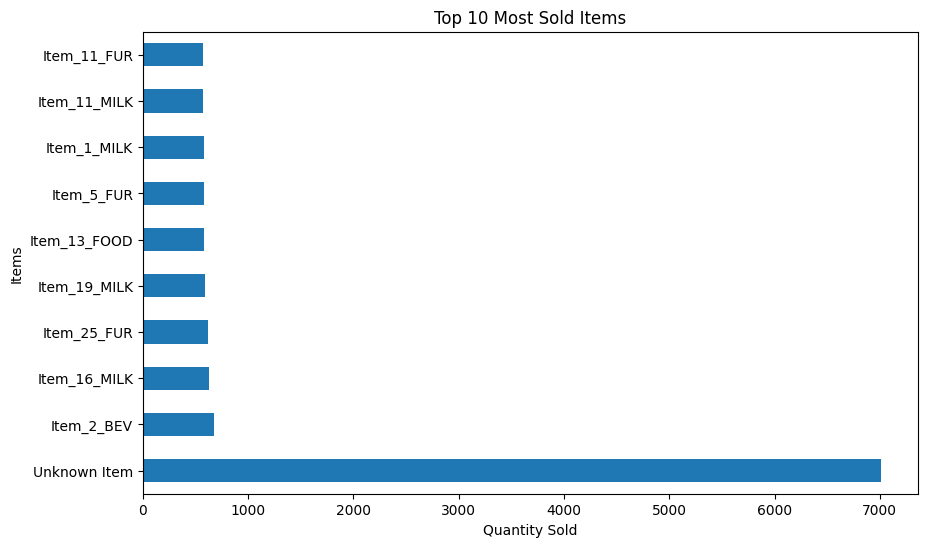

In [6]:
# Horizontal Bar Chart
plt.figure(figsize=(10,6))

top_10_items.plot(kind='barh')

plt.title('Top 10 Most Sold Items')
plt.xlabel('Quantity Sold')
plt.ylabel('Items')

plt.show()

In [7]:
# Question 3: Online vs In-store Sales
location_sales = df.groupby('Location')['Total Spent'].sum() #group by Location and sum Total Spent
print(location_sales)

Location
In-store    795173.0
Online      822432.0
Name: Total Spent, dtype: float64


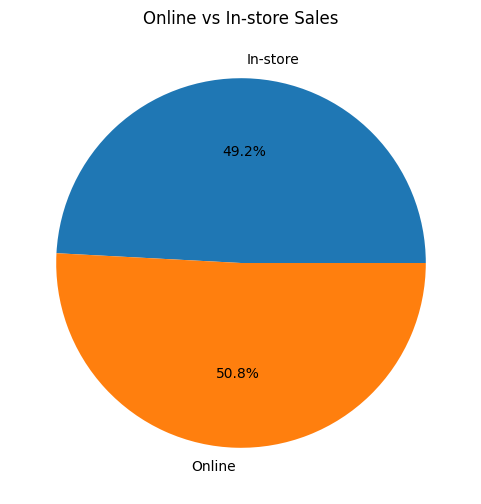

In [8]:
plt.figure(figsize=(6,6))

plt.pie(location_sales,
        labels=location_sales.index,
        autopct='%1.1f%%')

plt.title('Online vs In-store Sales')

plt.show()

2. Customer Buying Behavior
Question 1:
Which Customers Spend Most Money?

In [9]:
#Group by Customer
customer_spending = df.groupby('Customer ID')['Total Spent'].sum()

In [10]:
# Sort Highest to Lowest
top_customers = customer_spending.sort_values(ascending=False).head(10)

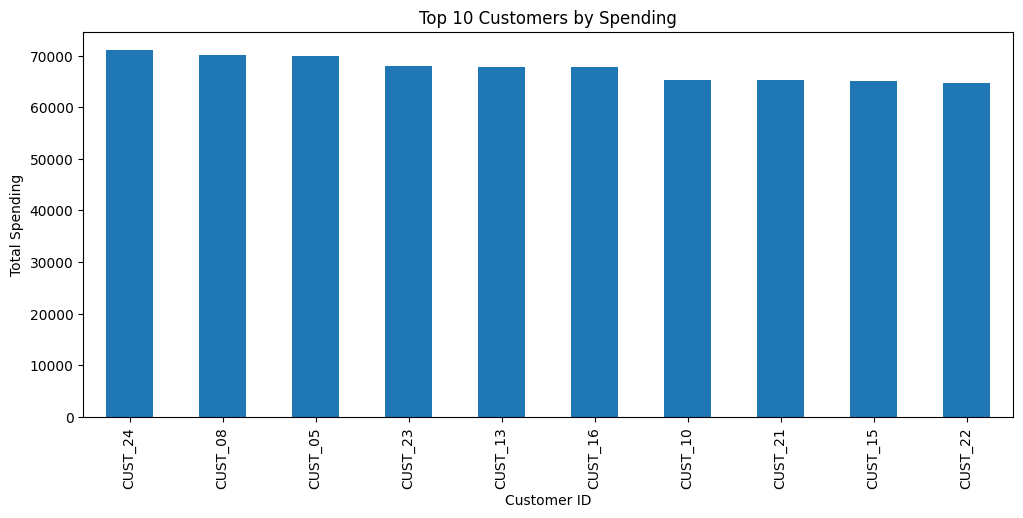

In [11]:
plt.figure(figsize=(12,5))

top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Spending')

plt.show()

Question 2:
Average Quantity Purchased

In [12]:
# Finding Average
average_quantity = df['Quantity'].mean()

print("Average Quantity Purchased:", average_quantity)

Average Quantity Purchased: 5.558648111332008


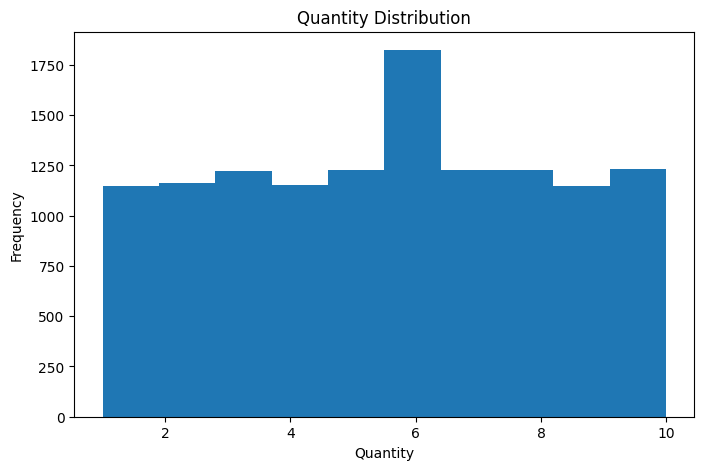

In [13]:
# Histogram
plt.figure(figsize=(8,5))

plt.hist(df['Quantity'])

plt.title('Quantity Distribution')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.show()

Question 3:
Do Customers Buy More When Discounts Are Applied?

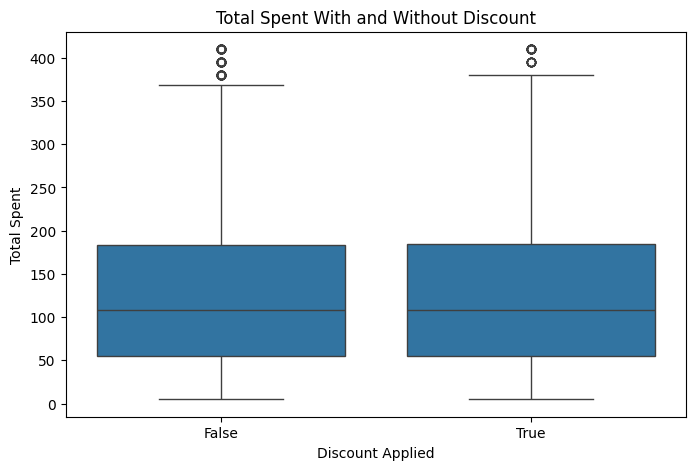

In [14]:
# Box plot
plt.figure(figsize=(8,5))

sns.boxplot(x='Discount Applied',
            y='Total Spent',
            data=df)

plt.title('Total Spent With and Without Discount')

plt.show()

3. Payment Method Analysis
Question 1:
Most Used Payment Method

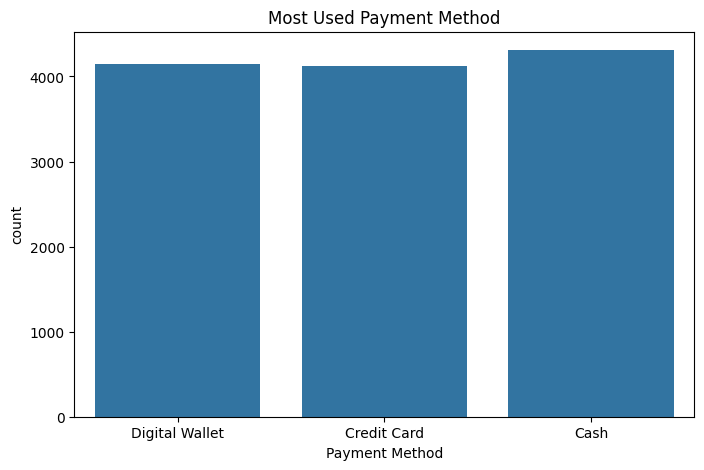

In [15]:
# Countplot
plt.figure(figsize=(8,5))

sns.countplot(x='Payment Method', data=df)

plt.title('Most Used Payment Method')

plt.show()

Question 2:
Which Payment Method Generates Highest Revenue?

In [16]:
# Group Data
payment_sales = df.groupby('Payment Method')['Total Spent'].sum()

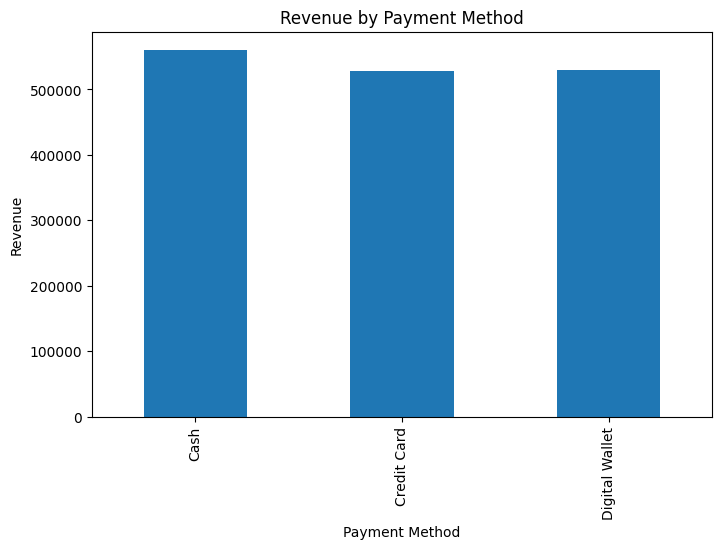

In [17]:
plt.figure(figsize=(8,5))

payment_sales.plot(kind='bar')

plt.title('Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Revenue')

plt.show()